
=== Inspecting real-test/d415 ===
File: 000000000-mask.png
  - Type (suffix): mask.png
  - Resolution: 848x480
  - Channels: 1
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
File: 000000000-normals.exr
  - Type (suffix): normals.exr
  - Resolution: 848x480
  - Channels: 3
  - DataType: float32
  - Min/Max: -1.0000 / 1.0000


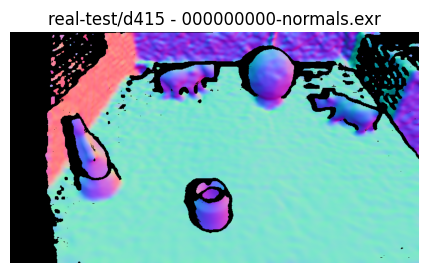

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.45288086..1.1503906].


File: 000000000-opaque-depth-img.exr
  - Type (suffix): opaque-depth-img.exr
  - Resolution: 848x480
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.4529 / 1.1504


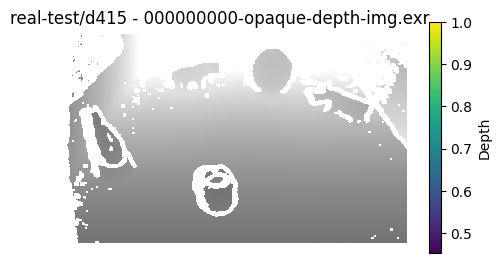

File: 000000000-opaque-rgb-img.jpg
  - Type (suffix): opaque-rgb-img.jpg
  - Resolution: 848x480
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
File: 000000000-output-depth.exr
  - Type (suffix): output-depth.exr
  - Resolution: 256x144
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0182 / 1.1455
File: 000000000-transparent-depth-img.exr
  - Type (suffix): transparent-depth-img.exr
  - Resolution: 848x480
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.1484
File: 000000000-transparent-rgb-img.jpg
  - Type (suffix): transparent-rgb-img.jpg
  - Resolution: 848x480
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
File: 000000034-transparent-rgb-img (copy).jpg
  - Type (suffix): transparent-rgb-img (copy).jpg
  - Resolution: 848x480
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
------------------------------------------------------------

=== Inspecting real-test/d435 ===
File: 000000000-mask.png
  - Type (suffi

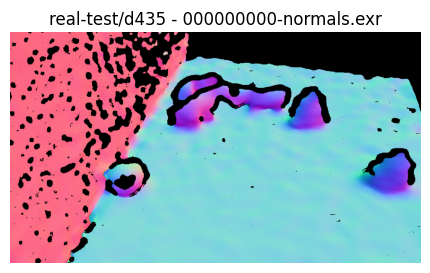

File: 000000000-opaque-depth-img.exr
  - Type (suffix): opaque-depth-img.exr
  - Resolution: 1280x720
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.0000


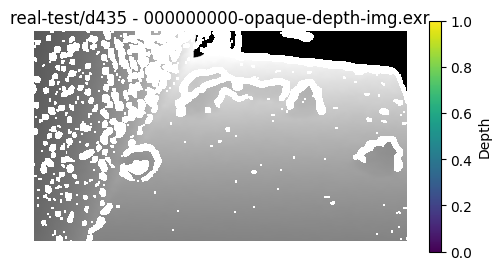

File: 000000000-opaque-rgb-img.jpg
  - Type (suffix): opaque-rgb-img.jpg
  - Resolution: 1280x720
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
File: 000000000-transparent-depth-img.exr
  - Type (suffix): transparent-depth-img.exr
  - Resolution: 1280x720
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.0000
File: 000000000-transparent-rgb-img.jpg
  - Type (suffix): transparent-rgb-img.jpg
  - Resolution: 1280x720
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
------------------------------------------------------------

=== Inspecting real-val/d435 ===
File: 000000000-mask.png
  - Type (suffix): mask.png
  - Resolution: 1280x720
  - Channels: 1
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
File: 000000000-normals.exr
  - Type (suffix): normals.exr
  - Resolution: 1280x720
  - Channels: 3
  - DataType: float32
  - Min/Max: -1.0000 / 1.0000


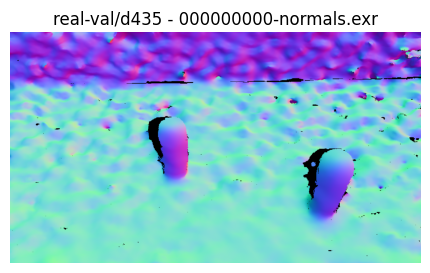

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0361328].


File: 000000000-opaque-depth-img.exr
  - Type (suffix): opaque-depth-img.exr
  - Resolution: 1280x720
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.0361


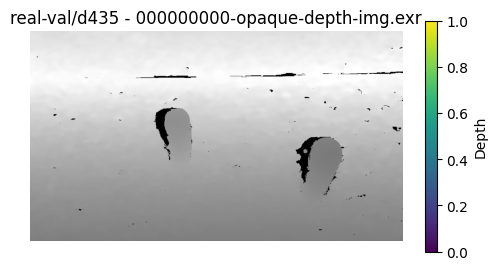

File: 000000000-opaque-rgb-img.jpg
  - Type (suffix): opaque-rgb-img.jpg
  - Resolution: 1280x720
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 167.0000
File: 000000000-transparent-depth-img.exr
  - Type (suffix): transparent-depth-img.exr
  - Resolution: 1280x720
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.0303
File: 000000000-transparent-rgb-img.jpg
  - Type (suffix): transparent-rgb-img.jpg
  - Resolution: 1280x720
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
------------------------------------------------------------

=== Inspecting synthetic-test/glass-round-potion-test ===
No image files found.

=== Inspecting synthetic-test/glass-square-potion-test ===
No image files found.

=== Inspecting synthetic-test/star-bath-bomb-test ===
No image files found.

=== Inspecting synthetic-test/tree-bath-bomb-test ===
No image files found.

=== Inspecting synthetic-val/cup-with-waves-val ===
No image files found.

=== Inspecting synthetic-va

In [1]:
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_root = 'dataset'  # relative to the notebook's working dir

IMG_EXTS = ('.exr', '.png', '.jpg', '.jpeg')

def inspect_dataset_subset(subset_name, subfolder):
    path = os.path.join(dataset_root, subset_name, subfolder)
    if not os.path.exists(path):
        print(f"Path does not exist: {path}")
        return

    print(f"\n=== Inspecting {subset_name}/{subfolder} ===")

    files = sorted([f for f in os.listdir(path) if f.lower().endswith(IMG_EXTS)])
    if not files:
        print("No image files found.")
        return

    # group by suffix/type (normals, opaque-depth-img, rgb, etc.)
    # convention: 000000000-normals.exr, 000000000-rgb.png, ...
    sample_types = {}
    for f in files:
        parts = f.split('-')
        if len(parts) > 1:
            suffix = '-'.join(parts[1:])  # e.g. "normals.exr", "rgb.png"
        else:
            suffix = f  # fallback for files without '-'
        sample_types.setdefault(suffix, f)

    viz_flags = {'depth': False, 'normals': False}

    for suffix, filename in sample_types.items():
        filepath = os.path.join(path, filename)

        # use IMREAD_UNCHANGED so we keep float for exr, etc.
        img = cv2.imread(filepath, cv2.IMREAD_UNCHANGED)
        if img is None:
            print(f"Could not read {filename}")
            continue

        h, w = img.shape[:2]
        c = img.shape[2] if img.ndim == 3 else 1

        print(f"File: {filename}")
        print(f"  - Type (suffix): {suffix}")
        print(f"  - Resolution: {w}x{h}")
        print(f"  - Channels: {c}")
        print(f"  - DataType: {img.dtype}")
        print(f"  - Min/Max: {np.nanmin(img):.4f} / {np.nanmax(img):.4f}")

        # Visualize one depth-like map (from exr or depth png)
        if ('depth' in suffix and not viz_flags['depth']):
            plt.figure(figsize=(6, 3))
            plt.title(f"{subset_name}/{subfolder} - {filename}")
            viz_img = img.astype(np.float32).copy()
            viz_img[np.isinf(viz_img)] = np.nan
            plt.imshow(viz_img, cmap='viridis')
            plt.colorbar(label='Depth')
            plt.axis('off')
            plt.show()
            viz_flags['depth'] = True

        # Visualize one normal map
        if ('normals' in suffix and not viz_flags['normals']):
            plt.figure(figsize=(6, 3))
            plt.title(f"{subset_name}/{subfolder} - {filename}")
            viz_img = img.astype(np.float32)
            # if normals saved as [-1,1], map to [0,1]; if [0,255] uint8, normalize
            if img.dtype == np.float32 or img.dtype == np.float64:
                viz_img = (viz_img + 1.0) / 2.0
            else:
                viz_img = viz_img / 255.0
            if viz_img.ndim == 3 and viz_img.shape[2] == 3:
                viz_img = cv2.cvtColor(viz_img, cv2.COLOR_BGR2RGB)
            plt.imshow(np.clip(viz_img, 0, 1))
            plt.axis('off')
            plt.show()
            viz_flags['normals'] = True

    print("-" * 60)


# ---- Run inspections ----

# 1) Real test: d415 and d435 if present
for cam in ['d415', 'd435']:
    if os.path.exists(os.path.join(dataset_root, 'real-test', cam)):
        inspect_dataset_subset('real-test', cam)

# 2) Real val: d415 and d435 if present
for cam in ['d415', 'd435']:
    if os.path.exists(os.path.join(dataset_root, 'real-val', cam)):
        inspect_dataset_subset('real-val', cam)

# 3) Synthetic test: all object folders
synthetic_test_root = os.path.join(dataset_root, 'synthetic-test')
if os.path.exists(synthetic_test_root):
    subdirs = sorted(
        d for d in os.listdir(synthetic_test_root)
        if os.path.isdir(os.path.join(synthetic_test_root, d))
    )
    for d in subdirs:
        inspect_dataset_subset('synthetic-test', d)

# 4) Synthetic val: all object folders
synthetic_val_root = os.path.join(dataset_root, 'synthetic-val')
if os.path.exists(synthetic_val_root):
    subdirs = sorted(
        d for d in os.listdir(synthetic_val_root)
        if os.path.isdir(os.path.join(synthetic_val_root, d))
    )
    for d in subdirs:
        inspect_dataset_subset('synthetic-val', d)